In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
PROCESSED_DIR = Path("/content/drive/MyDrive/data/processed")

data = np.load(PROCESSED_DIR / "auslan_classical_processed.npz")

X_train = data["X_train"]
y_train = data["y_train"]

X_test = data["X_test"]
y_test = data["y_test"]


print("Files: ",data.files)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Files:  ['X_train', 'y_train', 'X_test', 'y_test']
X_train: (1710, 1254)
X_test : (855, 1254)
y_train: (1710,)
y_test : (855,)


In [4]:
#Train and test linear SVM
svm_linear = SVC(
    kernel="linear",
    C=1.0
)
label_mapping = pd.read_csv(PROCESSED_DIR / "label_mapping.csv")

svm_linear.fit(X_train, y_train)
y_pred_train = svm_linear.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)

print(f"Linear SVM Train Accuracy: {accuracy_train:.4f}")

y_pred_test = svm_linear.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

target_names = label_mapping.sort_values("class_id")["sign"].tolist()

print(f"Linear SVM Test Accuracy: {accuracy_test:.4f}")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=target_names,
    digits=4
))

Linear SVM Train Accuracy: 1.0000
Linear SVM Test Accuracy: 0.9158
                precision    recall  f1-score   support

           God     0.9000    1.0000    0.9474         9
             I     0.6667    0.8889    0.7619         9
        Norway     1.0000    0.8889    0.9412         9
         alive     0.6667    0.8889    0.7619         9
           all     1.0000    1.0000    1.0000         9
        answer     1.0000    0.8889    0.9412         9
           boy     0.5556    0.5556    0.5556         9
      building     1.0000    1.0000    1.0000         9
           buy     1.0000    1.0000    1.0000         9
  change_mind_     0.8182    1.0000    0.9000         9
          cold     1.0000    1.0000    1.0000         9
          come     1.0000    0.5556    0.7143         9
  computer_PC_     1.0000    1.0000    1.0000         9
          cost     1.0000    1.0000    1.0000         9
         crazy     0.6667    0.6667    0.6667         9
        danger     0.8000    0.8889 

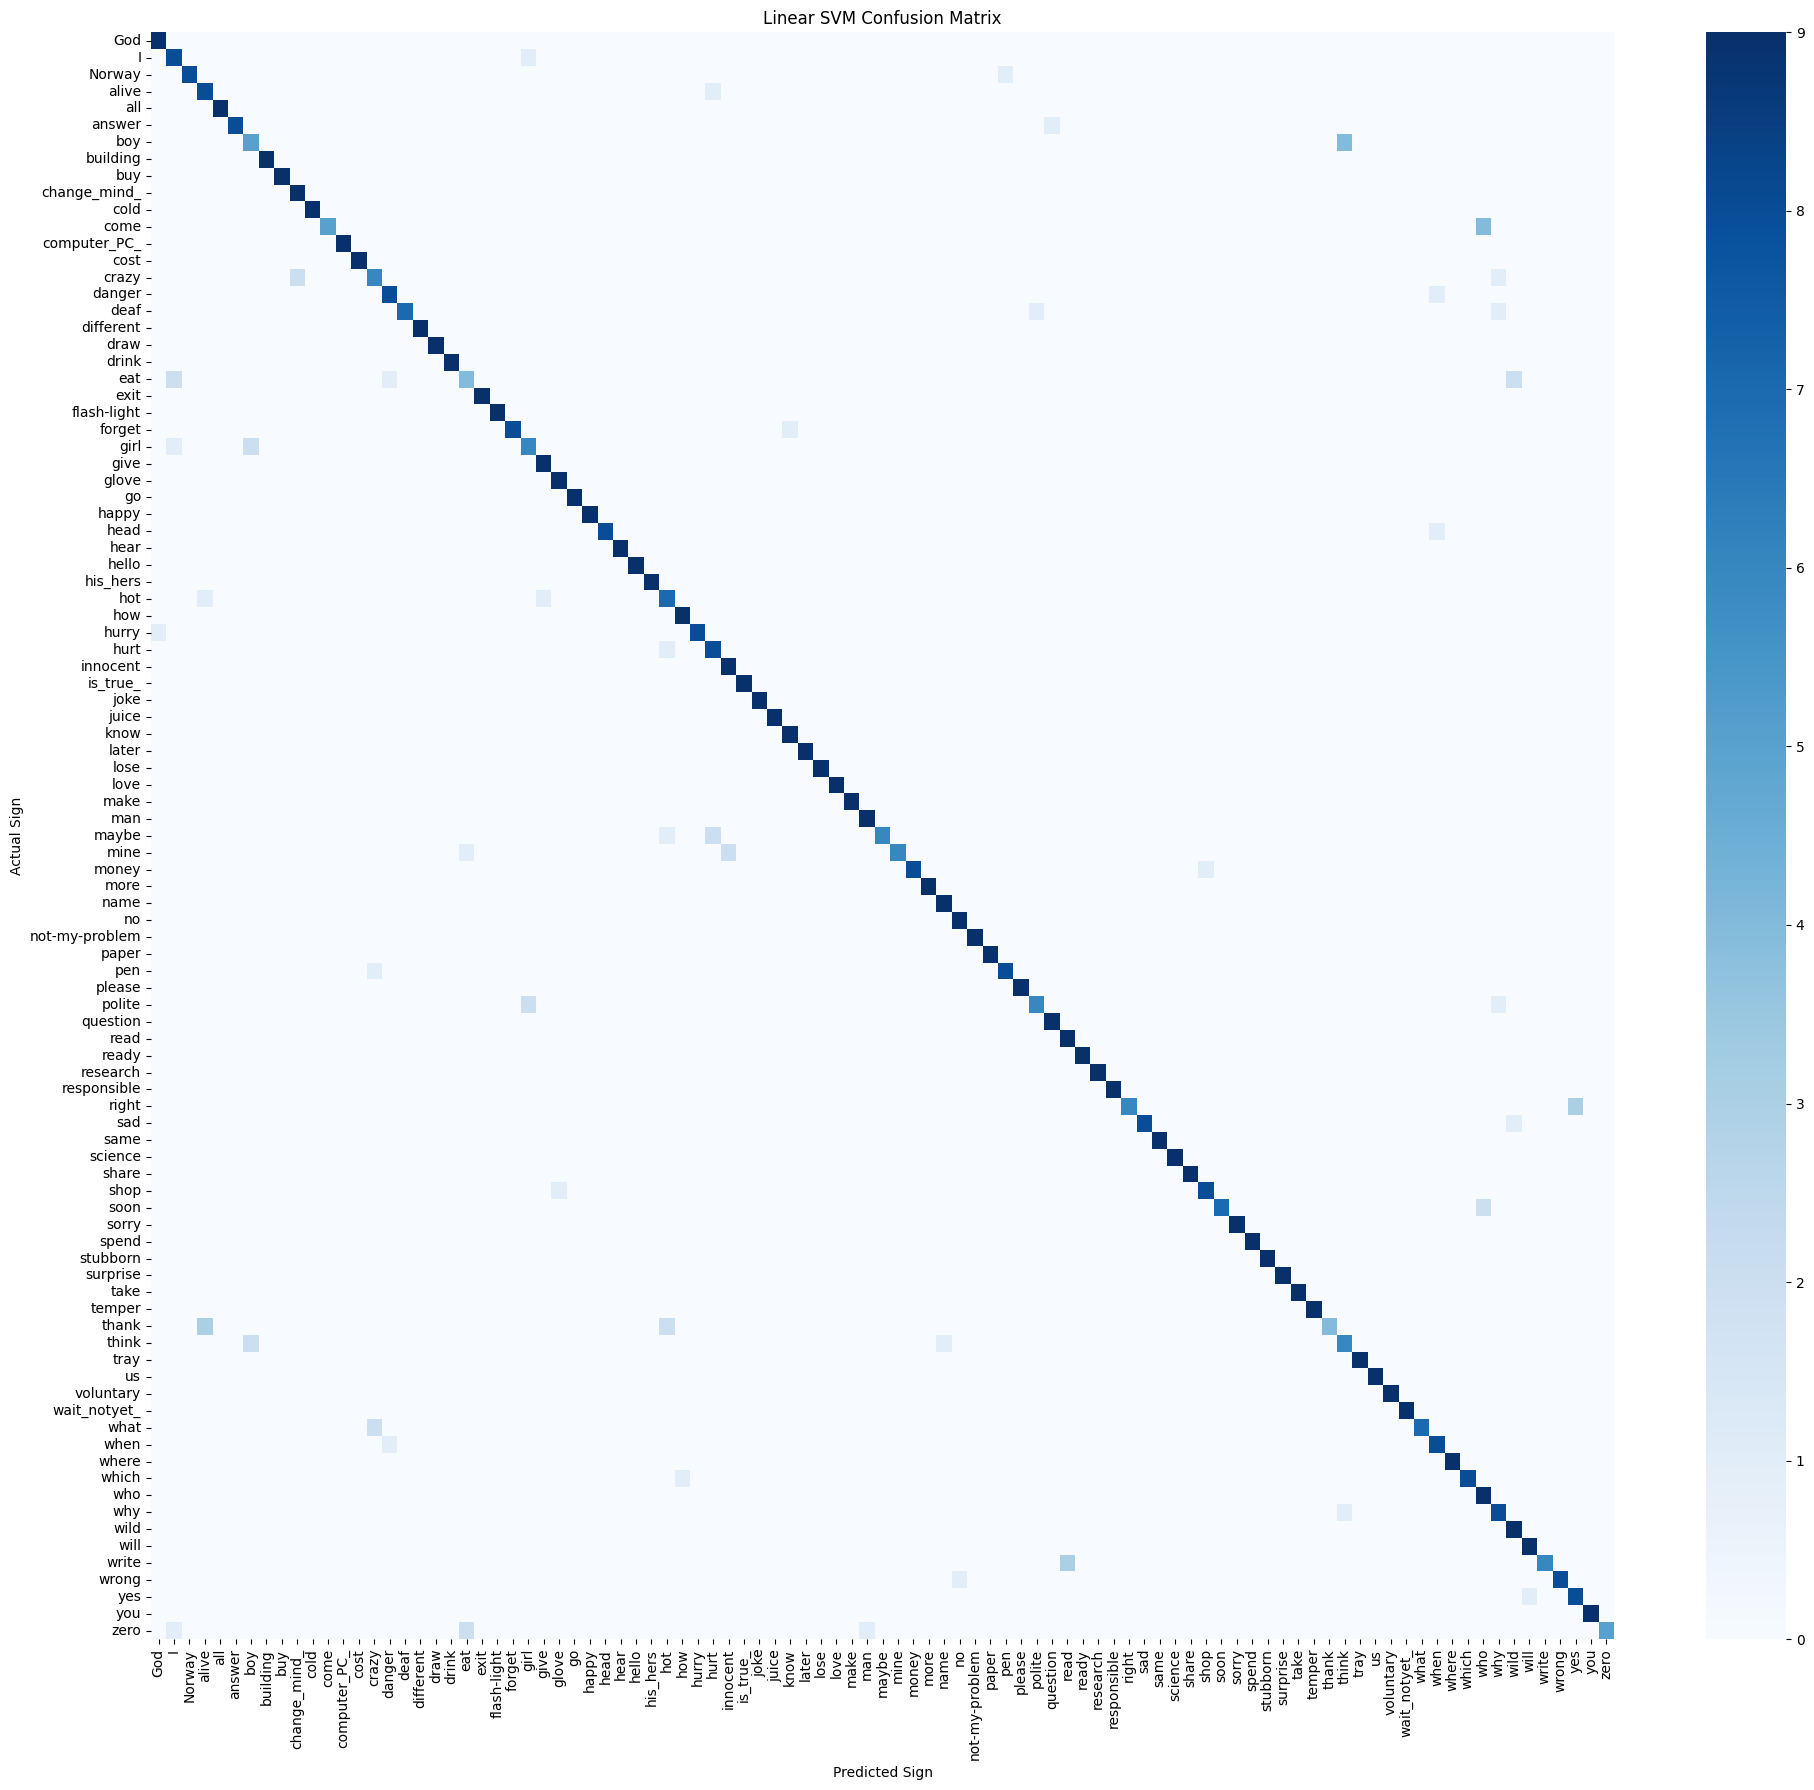

In [5]:
#Confusion matrix heatmap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Sign")
plt.ylabel("Actual Sign")
plt.title("Linear SVM Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [6]:
#Train and test RBF kernel SVM
svm_rbf = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale"
)

svm_rbf.fit(X_train, y_train)
y_pred_train = svm_rbf.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)

print(f"RBF SVM Train Accuracy: {accuracy_train:.4f}")

y_pred_test = svm_rbf.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"RBF SVM Test Accuracy: {accuracy_test:.4f}")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=target_names,
    digits=4
))

RBF SVM Train Accuracy: 1.0000
RBF SVM Test Accuracy: 0.9123
                precision    recall  f1-score   support

           God     0.9000    1.0000    0.9474         9
             I     0.6154    0.8889    0.7273         9
        Norway     1.0000    0.6667    0.8000         9
         alive     0.6667    0.8889    0.7619         9
           all     0.9000    1.0000    0.9474         9
        answer     1.0000    1.0000    1.0000         9
           boy     0.7500    0.6667    0.7059         9
      building     1.0000    1.0000    1.0000         9
           buy     1.0000    1.0000    1.0000         9
  change_mind_     0.8182    1.0000    0.9000         9
          cold     1.0000    1.0000    1.0000         9
          come     1.0000    0.6667    0.8000         9
  computer_PC_     1.0000    1.0000    1.0000         9
          cost     1.0000    1.0000    1.0000         9
         crazy     0.4545    0.5556    0.5000         9
        danger     0.9000    1.0000    0.9

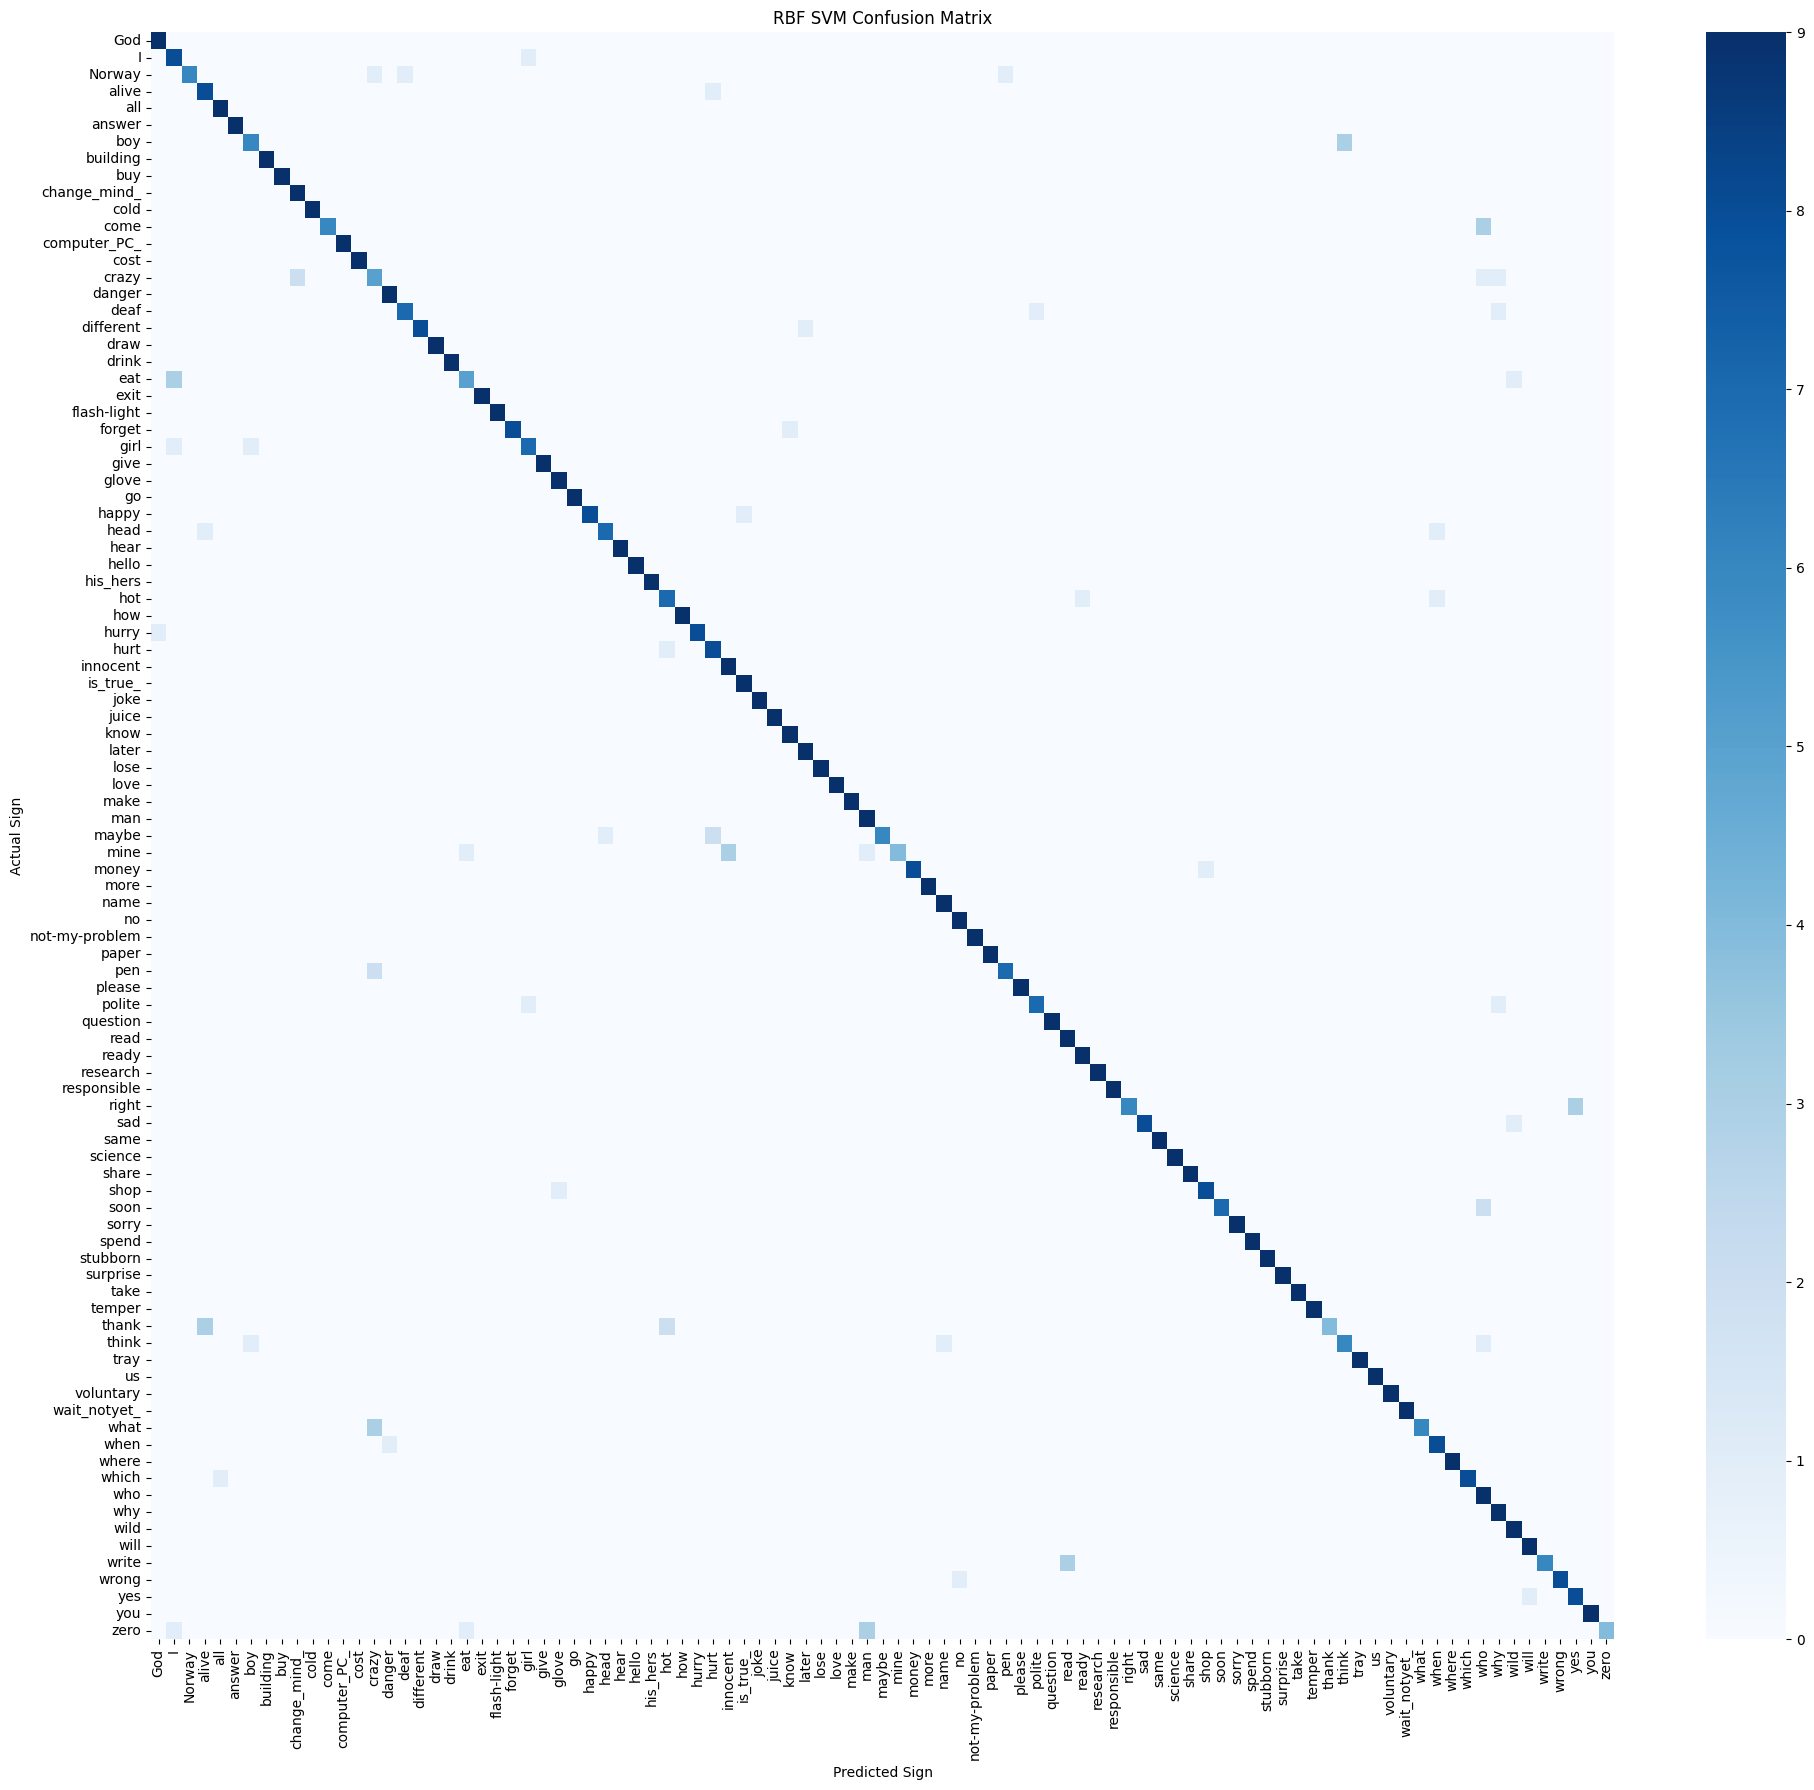

In [7]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Sign")
plt.ylabel("Actual Sign")
plt.title("RBF SVM Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()